<a href="https://colab.research.google.com/github/DiFedorchuk/Quora_Questions_Pairs/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords
from matplotlib.ticker import ScalarFormatter
%matplotlib inline
sns.set_style("whitegrid")
pal = sns.color_palette()
stops = set(stopwords.words("english"))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Load data

In [2]:
df_train = pd.read_csv("quora_question_pairs_train.csv.zip")
df_test = pd.read_csv("quora_question_pairs_test.csv.zip")

display(df_train.head())
display(df_test.head())

,id,qid1,qid2,question1,question2,is_duplicate
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0
1,196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0
2,113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0
3,266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0
4,122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1


,id,qid1,qid2,question1,question2,is_duplicate
0,305985,429434,429435,Why is beef banned in India and not pork as well?,Is beef banned in india?,0
1,5193,10230,10231,At what valuation did Homejoy raise money in D...,Should a wealthy founder self-fund his second ...,0
2,123326,199422,199423,How do we judge?,How do I judge my love?,0
3,368557,327674,498931,Are Adderall and meth the same?,Are concerta and meth test the same?,0
4,369226,499645,499646,If you had internet access to only one site fo...,Why is there .co.uk for British internet sites...,0


Basic dataset overview

In [3]:
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("\nTrain columns:", df_train.columns.tolist())
print("Test columns:", df_test.columns.tolist())

print("\nMissing values in train:")
print(df_train.isnull().sum())

print("\nMissing values in test:")
print(df_test.isnull().sum())

print("\nClass balance in train:")
print(df_train["is_duplicate"].value_counts(normalize=True).sort_index())

Train shape: (323432, 6)
Test shape: (80858, 6)

Train columns: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']
Test columns: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']

Missing values in train:
id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

Missing values in test:
id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

Class balance in train:
is_duplicate
0    0.630803
1    0.369197
Name: proportion, dtype: float64


Train dataset has 323432 rows, Test dataset has 80858 rows. There are 2 missing values in question2 and 1 missing value in question1

Duplicate target distribution

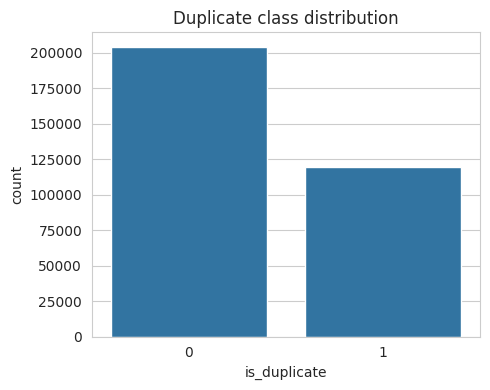

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(x="is_duplicate", data=df_train)
plt.title("Duplicate class distribution")
plt.xlabel("is_duplicate")
plt.ylabel("count")
plt.tight_layout()

Based on the distribution of duplicates, I noticed that there is an imbalance between the classes. There are approximately 200000 pairs of questions that are not duplicates (about 63%) and approximately 120000 pairs of duplicate questions (about 37%)

Question repetition analysis

In [5]:
train_qids = pd.Series(df_train["qid1"].tolist() + df_train["qid2"].tolist())
test_qids = pd.Series(df_test["qid1"].tolist() + df_test["qid2"].tolist())

Train dataset

Total number of question pairs for training dataset: 323432
Duplicate pairs: 36.92%
Total number of questions in the training dataset: 449792
Number of questions that appear multiple times: 85897


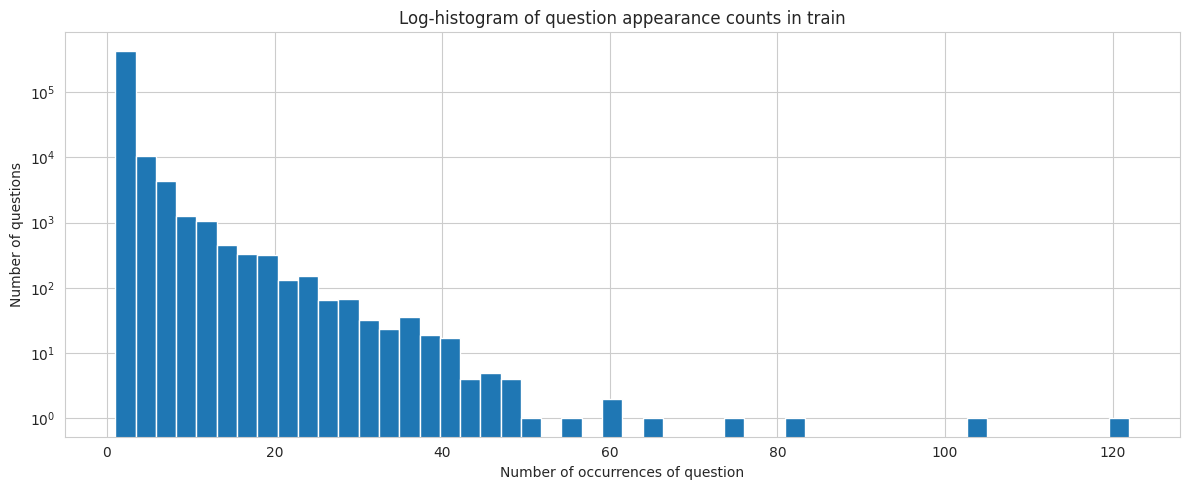

In [6]:

print("Total number of question pairs for training dataset: {}".format(len(df_train)))
print("Duplicate pairs: {}%".format(round(df_train["is_duplicate"].mean() * 100, 2)))
print("Total number of questions in the training dataset: {}".format(len(np.unique(train_qids))))
print("Number of questions that appear multiple times: {}".format(np.sum(train_qids.value_counts() > 1)))

plt.figure(figsize=(12, 5))
plt.hist(train_qids.value_counts(), bins=50)
plt.yscale("log", nonpositive="clip")
plt.title("Log-histogram of question appearance counts in train")
plt.xlabel("Number of occurrences of question")
plt.ylabel("Number of questions")
plt.tight_layout()

Most questions appear only a few times, only a few of them are repeated several times (and a few appear very frequently). One question appears more than 120 times, but that is an exception.
In this dataset, positive examples account for 37% of the total.

Test Dataset

Total number of question pairs for test dataset: 80858
Duplicate pairs: N/A for test set
Total number of questions in the test dataset: 137780
Number of questions that appear multiple times: 14354


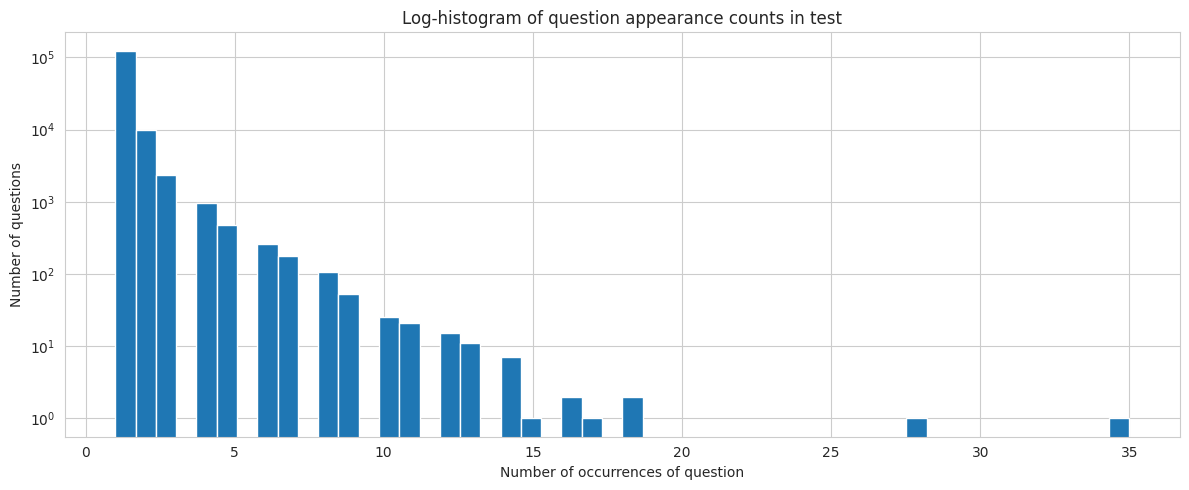

In [7]:
print("Total number of question pairs for test dataset: {}".format(len(df_test)))
print("Duplicate pairs: N/A for test set")
print("Total number of questions in the test dataset: {}".format(len(np.unique(test_qids))))
print("Number of questions that appear multiple times: {}".format(np.sum(test_qids.value_counts() > 1)))

plt.figure(figsize=(12, 5))
plt.hist(test_qids.value_counts(), bins=50)
plt.yscale("log", nonpositive="clip")
plt.title("Log-histogram of question appearance counts in test")
plt.xlabel("Number of occurrences of question")
plt.ylabel("Number of questions")
plt.tight_layout()

As in the training dataset, most questions appear only a few times. A small number of questions are repeated many times, as evidenced by the long tail of the distribution

##Text length analysis

char length -> mean-train 59.83 std-train 31.97 mean-test 59.80 std-test 31.94 max-train 1169.00 max-test 1169.00
word length -> mean-train 11.06 std-train 5.89 mean-test 11.06 std-test 5.87 max-train 237.00 max-test 237.00


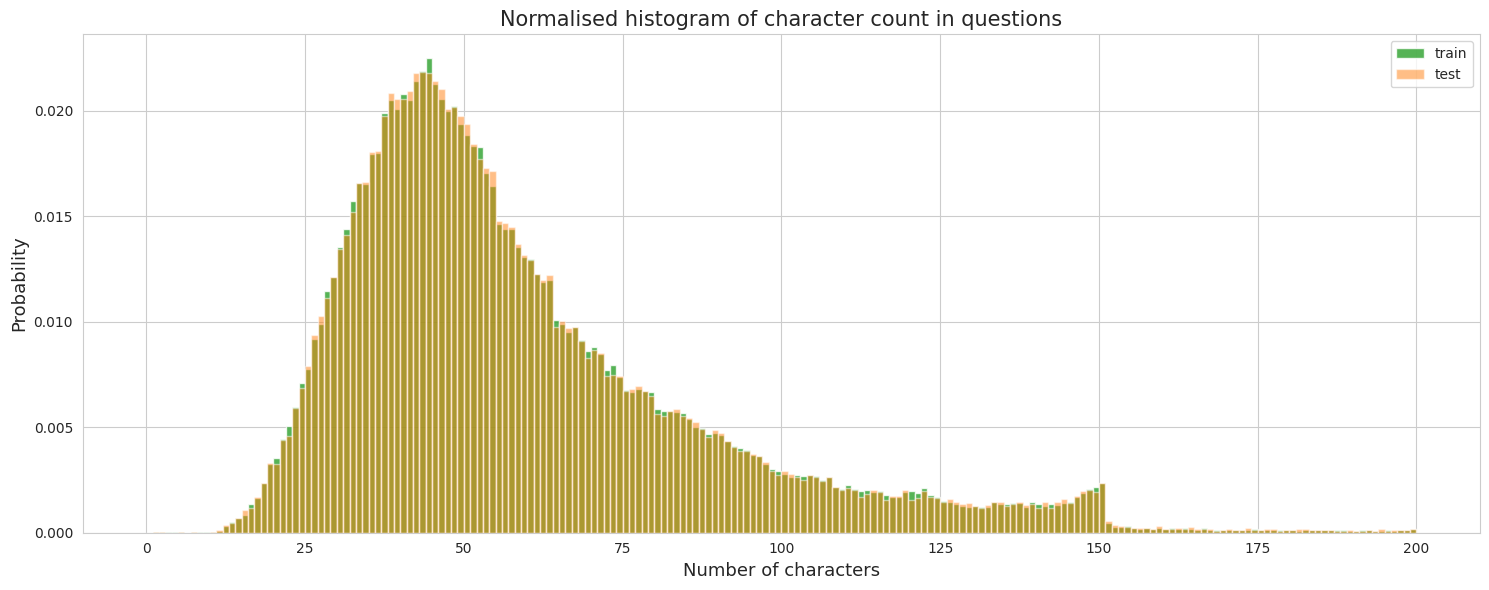

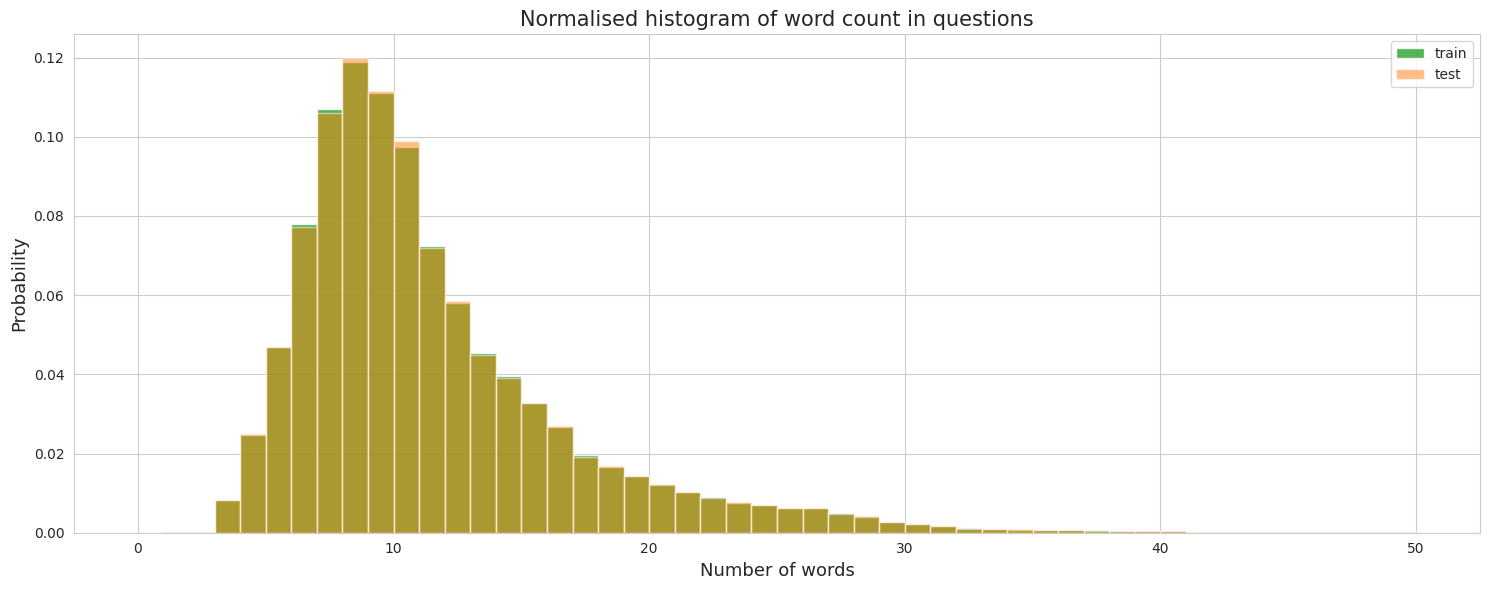

In [8]:
train_qs = pd.Series(df_train["question1"].tolist() + df_train["question2"].tolist()).astype(str)
test_qs = pd.Series(df_test["question1"].tolist() + df_test["question2"].tolist()).astype(str)

train_char_len = train_qs.apply(len)
test_char_len = test_qs.apply(len)

plt.figure(figsize=(15, 6))
plt.hist(train_char_len, bins=200, range=[0, 200], color=pal[2], density=True, label="train", alpha=0.8)
plt.hist(test_char_len, bins=200, range=[0, 200], color=pal[1], density=True, alpha=0.5, label="test")
plt.title("Normalised histogram of character count in questions", fontsize=15)
plt.legend()
plt.xlabel("Number of characters", fontsize=13)
plt.ylabel("Probability", fontsize=13)
plt.tight_layout()

print(
    "char length -> mean-train {:.2f} std-train {:.2f} mean-test {:.2f} std-test {:.2f} max-train {:.2f} max-test {:.2f}".format(
        train_char_len.mean(),
        train_char_len.std(),
        test_char_len.mean(),
        test_char_len.std(),
        train_char_len.max(),
        test_char_len.max(),
    )
)

train_word_len = train_qs.apply(lambda x: len(x.split()))
test_word_len = test_qs.apply(lambda x: len(x.split()))

plt.figure(figsize=(15, 6))
plt.hist(train_word_len, bins=50, range=[0, 50], color=pal[2], density=True, label="train", alpha=0.8)
plt.hist(test_word_len, bins=50, range=[0, 50], color=pal[1], density=True, alpha=0.5, label="test")
plt.title("Normalised histogram of word count in questions", fontsize=15)
plt.legend()
plt.xlabel("Number of words", fontsize=13)
plt.ylabel("Probability", fontsize=13)
plt.tight_layout()

print(
    "word length -> mean-train {:.2f} std-train {:.2f} mean-test {:.2f} std-test {:.2f} max-train {:.2f} max-test {:.2f}".format(
        train_word_len.mean(),
        train_word_len.std(),
        test_word_len.mean(),
        test_word_len.std(),
        train_word_len.max(),
        test_word_len.max(),
    )
)

Character Count observations:


The histograms for both the training and test datasets show very similar distributions of character counts, both of which are right-skewed.
Most questions contain approximately 20 to 80 characters, with a peak at 40–50 characters. There is a long tail extending up to 150–170 characters, indicating the presence of some significantly longer, less frequent queries.
The mean, standard deviation, and maximum number of characters in the training and test sets are very close, indicating data consistency and good potential for model generalization.


Word Count observation:


Both the training and test datasets exhibit very similar right-skewed distributions in terms of word count.
Most questions contain approximately 5 to 15 words, with a peak at 8–10 words.
The average number of words, standard deviation, and maximum number of words in the training and test datasets are very similar, which further confirms the consistency of the data.



##Semantic Analysis

In [ ]:
qmarks = np.mean(train_qs.apply(lambda x: "?" in x))
math = np.mean(train_qs.apply(lambda x: "[math]" in x))
fullstop = np.mean(train_qs.apply(lambda x: "." in x))
capital_first = np.mean(train_qs.apply(lambda x: x[0].isupper()))
capitals = np.mean(train_qs.apply(lambda x: any(y.isupper() for y in x)))
numbers = np.mean(train_qs.apply(lambda x: any(y.isdigit() for y in x)))

print("Questions with question marks: {:.2f}%".format(qmarks * 100))
print("Questions with [math] tags: {:.2f}%".format(math * 100))
print("Questions with full stops: {:.2f}%".format(fullstop * 100))
print("Questions with capitalised first letters: {:.2f}%".format(capital_first * 100))
print("Questions with capital letters: {:.2f}%".format(capitals * 100))
print("Questions with numbers: {:.2f}%".format(numbers * 100))

Questions with question marks: 99.88%
Questions with [math] tags: 0.12%
Questions with full stops: 6.31%
Questions with capitalised first letters: 99.82%
Questions with capital letters: 99.95%
Questions with numbers: 11.85%


The dataset exhibits strong linguistic consistency, as nearly all questions contain a question mark 99,88% and begin with a capital letter 99,82%, reflecting proper grammatical structure and readability. Numerical content appears in approximately 11,85% of questions, indicating that a notable subset of queries involves quantities, dates, or other numeric information. In contrast, mathematical tags 0,12% and periods 6,31% are relatively rare, which is expected given the nature of question-based text, where sentences typically end with question marks and specialized mathematical content is uncommon. Overall, these findings suggest that the dataset is well-structured and follows standard conventions of written questions, making it suitable for natural language processing and question-pair analysis tasks

##Feature Analysis

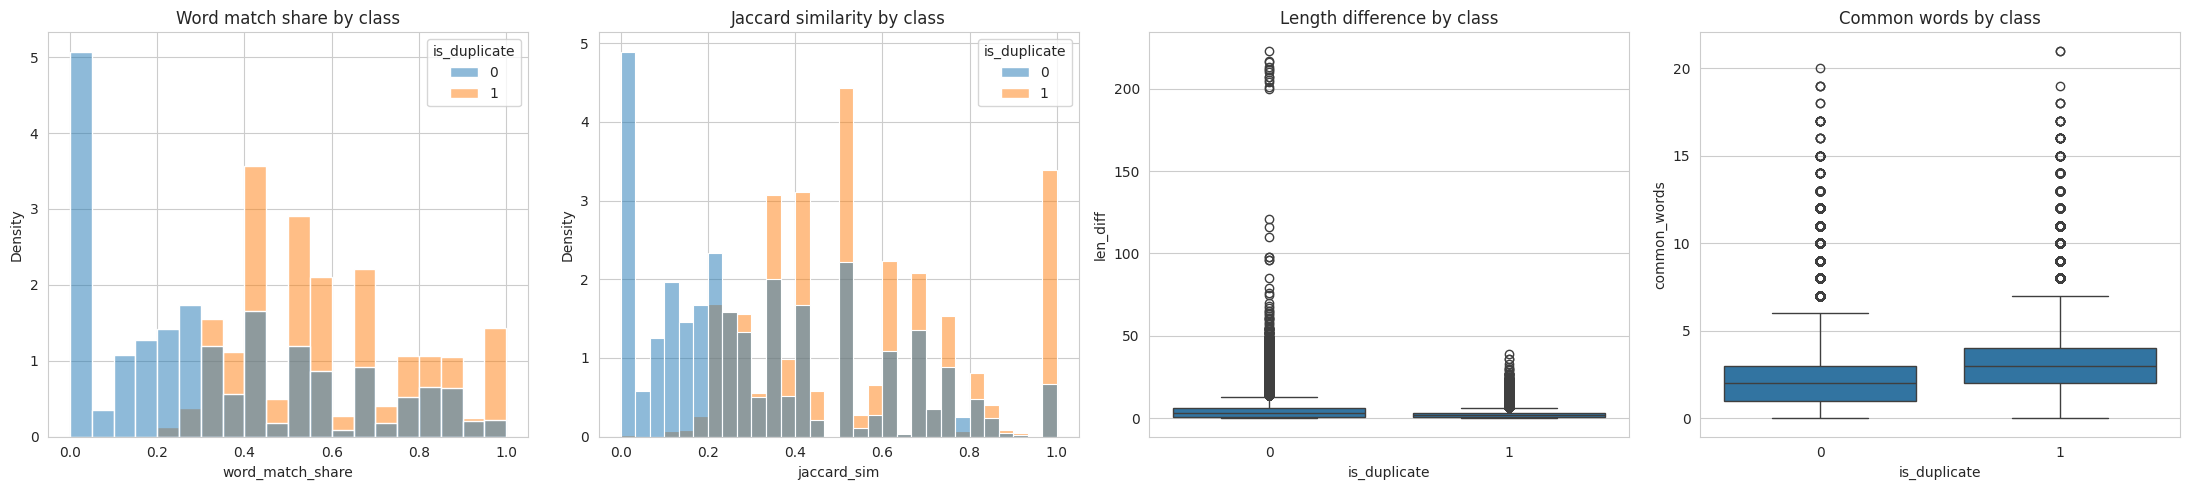

In [ ]:
def word_match_share(row):
    q1words = {}
    q2words = {}

    for word in str(row["question1"]).lower().split():
        if word not in stops:
            q1words[word] = 1

    for word in str(row["question2"]).lower().split():
        if word not in stops:
            q2words[word] = 1

    if len(q1words) == 0 or len(q2words) == 0:
        return 0

    shared_words_in_q1 = [w for w in q1words.keys() if w in q2words]
    shared_words_in_q2 = [w for w in q2words.keys() if w in q1words]
    return (len(shared_words_in_q1) + len(shared_words_in_q2)) / (len(q1words) + len(q2words))

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return [w for w in text.split() if w and w not in stops]

def jaccard_similarity(row):
    q1 = set(tokenize(row["question1"]))
    q2 = set(tokenize(row["question2"]))
    if not q1 or not q2:
        return 0.0
    return len(q1 & q2) / len(q1 | q2)

def common_word_count(row):
    q1 = set(tokenize(row["question1"]))
    q2 = set(tokenize(row["question2"]))
    return len(q1 & q2)

df_train["q1_len"] = df_train["question1"].astype(str).apply(lambda x: len(x.split()))
df_train["q2_len"] = df_train["question2"].astype(str).apply(lambda x: len(x.split()))
df_train["len_diff"] = (df_train["q1_len"] - df_train["q2_len"]).abs()
df_train["common_words"] = df_train.apply(common_word_count, axis=1)
df_train["jaccard_sim"] = df_train.apply(jaccard_similarity, axis=1)
df_train["word_match_share"] = df_train.apply(word_match_share, axis=1)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

sns.histplot(
    data=df_train, x="word_match_share", hue="is_duplicate",
    bins=20, stat="density", common_norm=False, ax=axes[0]
)
axes[0].set_title("Word match share by class")

sns.histplot(
    data=df_train, x="jaccard_sim", hue="is_duplicate",
    bins=30, stat="density", common_norm=False, ax=axes[1]
)
axes[1].set_title("Jaccard similarity by class")

sns.boxplot(data=df_train, x="is_duplicate", y="len_diff", ax=axes[2])
axes[2].set_title("Length difference by class")

sns.boxplot(data=df_train, x="is_duplicate", y="common_words", ax=axes[3])
axes[3].set_title("Common words by class")

plt.tight_layout()

The analysis demonstrates that duplicate question pairs exhibit significantly higher lexical similarity than non-duplicate pairs. Features such as word_match_share, Jaccard similarity, and the number of shared words consistently show higher values for duplicate questions, indicating a greater overlap in vocabulary. Additionally, duplicate questions tend to have more similar lengths, while non-duplicate pairs display larger differences in word count. Overall, lexical overlap and similarity in question length are strong indicators of question duplication and can serve as effective features for duplicate question detection models



Question frequency features

What are the best ways to lose weight?                                                                                        126
How can you look at someone's private Instagram account without following them?                                               103
How can I lose weight quickly?                                                                                                 83
What's the easiest way to make money online?                                                                                   74
What are some things new employees should know going into their first day at AT&T?                                             64
Can you see who views your Instagram?                                                                                          61
What do you think of the decision by the Indian Government to demonetize 500 and 1000 rupee notes?                             60
Which is the best digital marketing course?                                               

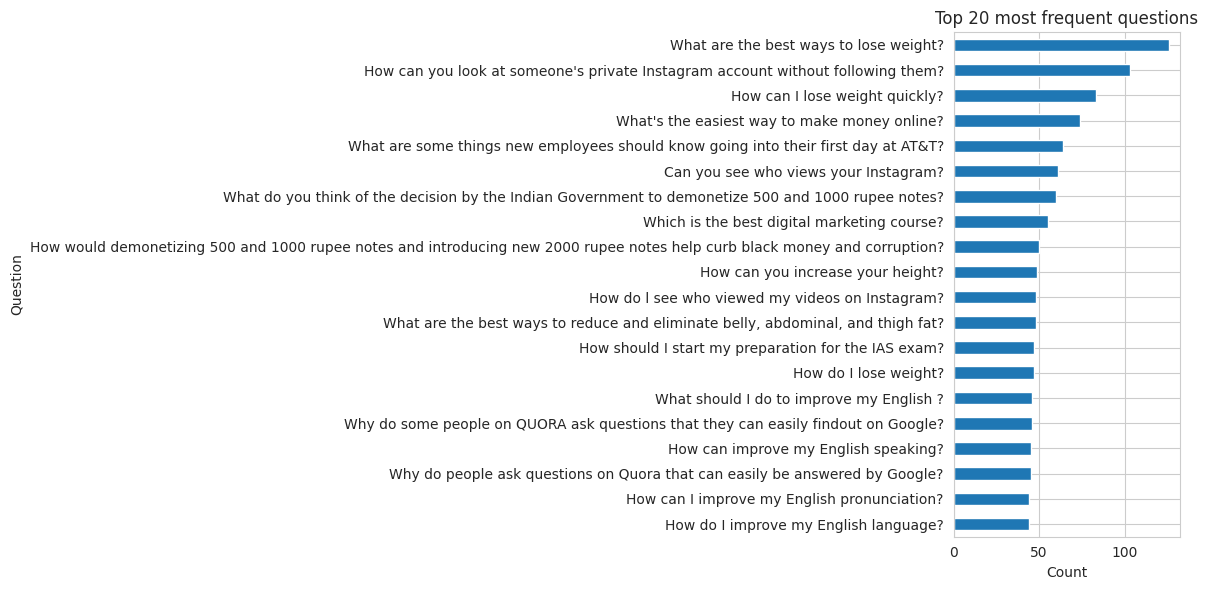

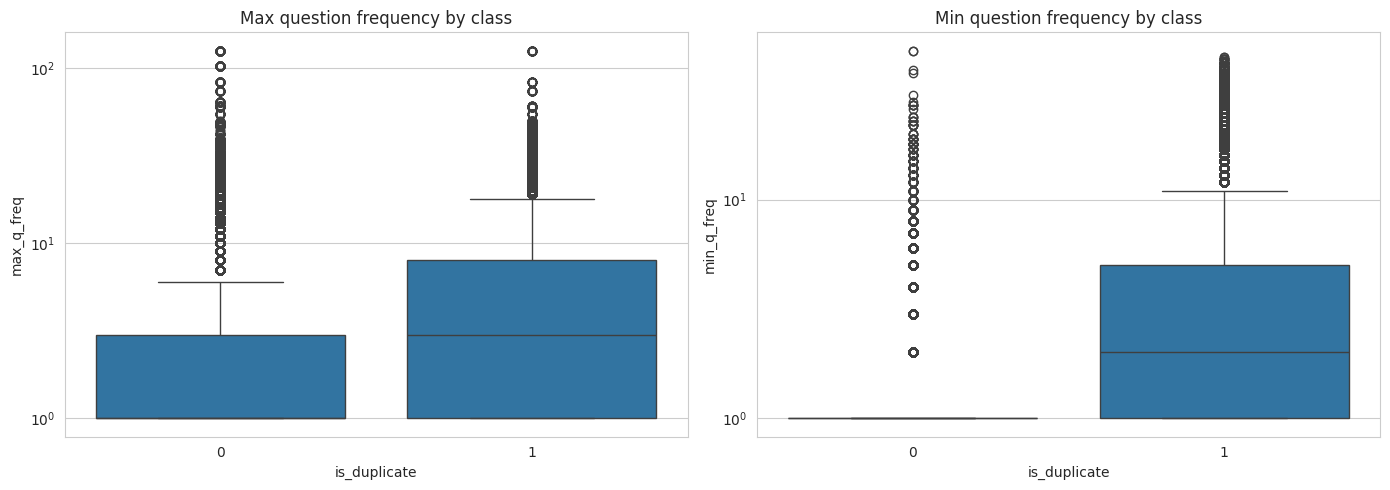

In [ ]:
all_questions = pd.Series(pd.concat([df_train["question1"], df_train["question2"]]).astype(str))
question_freq = all_questions.value_counts()
top_questions = question_freq.head(20)

plt.figure(figsize=(12, 6))
top_questions.sort_values().plot(kind="barh")
plt.title("Top 20 most frequent questions")
plt.xlabel("Count")
plt.ylabel("Question")
plt.tight_layout()

print(top_questions)

q1_freq = df_train["question1"].map(question_freq)
q2_freq = df_train["question2"].map(question_freq)

df_train["max_q_freq"] = pd.concat([q1_freq, q2_freq], axis=1).max(axis=1)
df_train["min_q_freq"] = pd.concat([q1_freq, q2_freq], axis=1).min(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_train, x="is_duplicate", y="max_q_freq", ax=axes[0])
axes[0].set_title("Max question frequency by class")
axes[0].set_yscale("log")

sns.boxplot(data=df_train, x="is_duplicate", y="min_q_freq", ax=axes[1])
axes[1].set_title("Min question frequency by class")
axes[1].set_yscale("log")

plt.tight_layout()

The analysis of question frequency features reveals that a small number of questions appear very frequently in the dataset, reflecting popular and commonly discussed topics. Duplicate question pairs tend to have higher maximum and minimum question frequencies than non-duplicate pairs, indicating that questions that recur often are more likely to form duplicate pairs. This suggests that question frequency is a valuable predictor of duplication, as frequently asked questions are more prone to being repeated and matched with semantically similar queries. Overall, frequency-based features provide important insights and can significantly enhance the performance of duplicate question detection models

Train/test question overlap

In [ ]:
train_questions = pd.Index(pd.unique(pd.concat([df_train["question1"], df_train["question2"]]).astype(str)))
test_questions = pd.Index(pd.unique(pd.concat([df_test["question1"], df_test["question2"]]).astype(str)))
overlap = train_questions.intersection(test_questions)

print(f"Unique questions in train: {len(train_questions)}")
print(f"Unique questions in test: {len(test_questions)}")
print(f"Overlap questions: {len(overlap)}")
print(f"Overlap ratio vs train: {len(overlap) / len(train_questions):.2%}")
print(f"Overlap ratio vs test: {len(overlap) / len(test_questions):.2%}")

Unique questions in train: 449364
Unique questions in test: 137701
Overlap questions: 49704
Overlap ratio vs train: 11.06%
Overlap ratio vs test: 36.10%


The analysis shows that the training and test datasets share a substantial number of questions, with approximately 49704 overlapping questions. While this overlap accounts for only 11,06% of the unique questions in the training set, it represents a much larger 36,10% of the unique questions in the test set. This suggests that a significant portion of the test data consists of questions that have already appeared in the training data. Consequently, dataset overlap should be carefully considered during model development and evaluation, as it may lead to overly optimistic performance estimates if the validation process does not properly prevent information leakage. Ensuring a clear separation between training, validation, and test questions is essential for accurately assessing a model ability to generalize to unseen data